<h1><center>Xây dựng mô hình Random Forest cho bài toán phân loại thuốc</center></h1>

> **Nguồn tham khảo:**
> - Ref 1: https://github.com/AnjanaAbY/Drug-Classification-Model — so sánh 6 mô hình, hàm tính precision/recall/F1
> - Ref 2: https://github.com/ajaychouhan-nitbhopal/Drug-Classification-with-Random-forest-Classifier-on-Drug200-dataset — RF entropy + confusion matrix
> - Ref 3: https://gist.github.com/vikramsoni2/3293b5dab320ba6d67eb8eed415e1c04 — seaborn cubehelix confusion matrix
> - Ref 4: https://gist.github.com/shaypal5/94c53d765083101efc0240d776a23823 — reusable confusion matrix heatmap

Trong bài thực hành này, chúng ta sử dụng mô hình **Random Forest** để phân loại bệnh nhân vào các loại thuốc khác nhau (drugA, drugB, drugC, drugX, drugY). Ngoài ra bài cũng so sánh nhiều mô hình khác nhau và tối ưu siêu tham số bằng GridSearchCV.

## Nội dung thực hành

1. Import thư viện
2. Load dữ liệu
3. Tiền xử lý dữ liệu
4. Cài đặt và huấn luyện Random Forest
5. Dự đoán và đánh giá cơ bản
6. Đánh giá ảnh hưởng của các thuộc tính (feature importance)
7. Tối ưu tham số với GridSearchCV
8. So sánh các mô hình
9. Confusion matrix

---
## 1. Import thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

print('Tất cả thư viện đã được import thành công.')

Tất cả thư viện đã được import thành công.


---
## 2. Load dữ liệu

In [2]:
my_data = pd.read_csv('drug200.csv', delimiter=',')
print(f'Kích thước dữ liệu: {my_data.shape}')
my_data.head()

Kích thước dữ liệu: (200, 6)


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
print('Thông tin dữ liệu:')
print(my_data.info())
print('\nGiá trị null:')
print(my_data.isnull().sum())
print('\nPhân phối nhãn (Drug):')
print(my_data['Drug'].value_counts())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB
None

Giá trị null:
Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

Phân phối nhãn (Drug):
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


### Khám phá dữ liệu nhanh

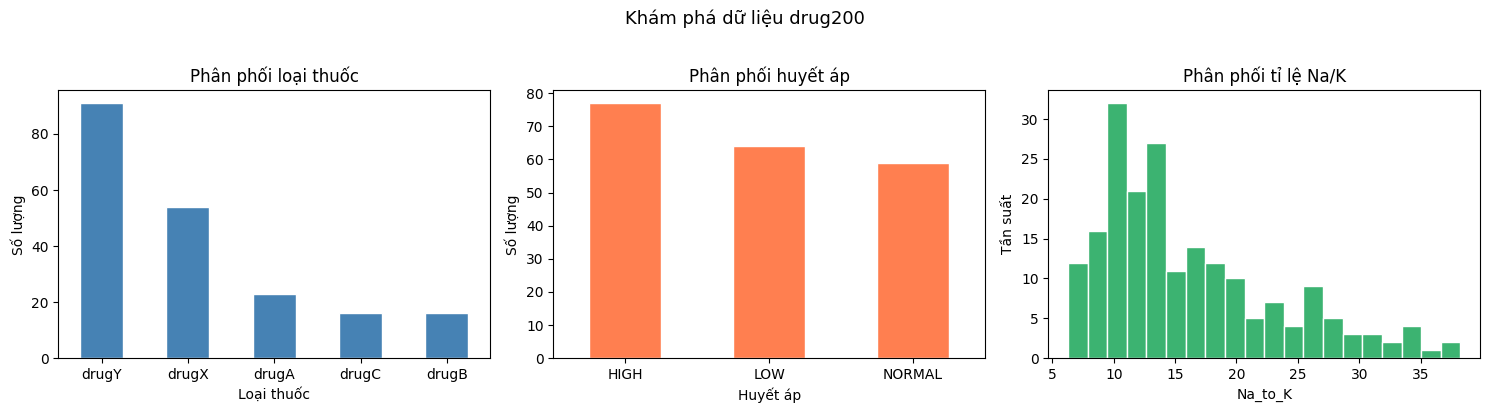

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

my_data['Drug'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Phân phối loại thuốc')
axes[0].set_xlabel('Loại thuốc')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=0)

my_data['BP'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Phân phối huyết áp')
axes[1].set_xlabel('Huyết áp')
axes[1].set_ylabel('Số lượng')
axes[1].tick_params(axis='x', rotation=0)

axes[2].hist(my_data['Na_to_K'], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Phân phối tỉ lệ Na/K')
axes[2].set_xlabel('Na_to_K')
axes[2].set_ylabel('Tần suất')

plt.suptitle('Khám phá dữ liệu drug200', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Tiền xử lý dữ liệu

Mã hoá các thuộc tính dạng categorical (Sex, BP, Cholesterol) về số thực bằng `LabelEncoder`.

In [5]:
X = my_data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values

le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F', 'M'])
X[:, 1] = le_sex.transform(X[:, 1])

le_BP = preprocessing.LabelEncoder()
le_BP.fit(['LOW', 'NORMAL', 'HIGH'])
X[:, 2] = le_BP.transform(X[:, 2])

le_Chol = preprocessing.LabelEncoder()
le_Chol.fit(['NORMAL', 'HIGH'])
X[:, 3] = le_Chol.transform(X[:, 3])

y = my_data['Drug']

print('5 mẫu đầu sau khi mã hoá:')
print(X[0:5])

5 mẫu đầu sau khi mã hoá:
[[23 0 0 0 25.355]
 [47 1 1 0 13.093]
 [47 1 1 0 10.114]
 [28 0 2 0 7.798]
 [61 0 1 0 18.043]]


Chia dữ liệu thành tập **train (70%)** và **test (30%)**.

In [6]:
X_trainset, X_testset, y_trainset, y_testset = train_test_split(
    X, y, test_size=0.3, random_state=3
)

In [7]:
# Kích thước tập train
print('X_trainset shape:', X_trainset.shape)
print('y_trainset shape:', y_trainset.shape)

X_trainset shape: (140, 5)
y_trainset shape: (140,)


In [8]:
# Kích thước tập test
print('X_testset shape:', X_testset.shape)
print('y_testset shape:', y_testset.shape)

X_testset shape: (60, 5)
y_testset shape: (60,)


---
## 4. Cài đặt và huấn luyện Random Forest

In [9]:
drugTree = RandomForestClassifier(n_estimators=100, random_state=42)
drugTree.fit(X_trainset, y_trainset)
print('Huấn luyện hoàn tất.')

Huấn luyện hoàn tất.


---
## 5. Dự đoán và đánh giá cơ bản

In [10]:
predTree = drugTree.predict(X_testset)

print('Nhãn phán đoán:', predTree[0:5])
print('Nhãn đúng     :', list(y_testset)[0:5])

Nhãn phán đoán: ['drugY' 'drugX' 'drugX' 'drugX' 'drugX']
Nhãn đúng     : ['drugY', 'drugX', 'drugX', 'drugX', 'drugX']


In [11]:
acc = metrics.accuracy_score(y_testset, predTree)
print(f'Độ chính xác (accuracy) của Random Forest: {acc:.4f} ({acc*100:.2f}%)')

Độ chính xác (accuracy) của Random Forest: 0.9833 (98.33%)


---
## 6. Đánh giá ảnh hưởng của các thuộc tính (feature importance)

Điểm số `feature_importances_` cho biết thuộc tính nào đóng góp nhiều nhất khi Random Forest đưa ra quyết định.

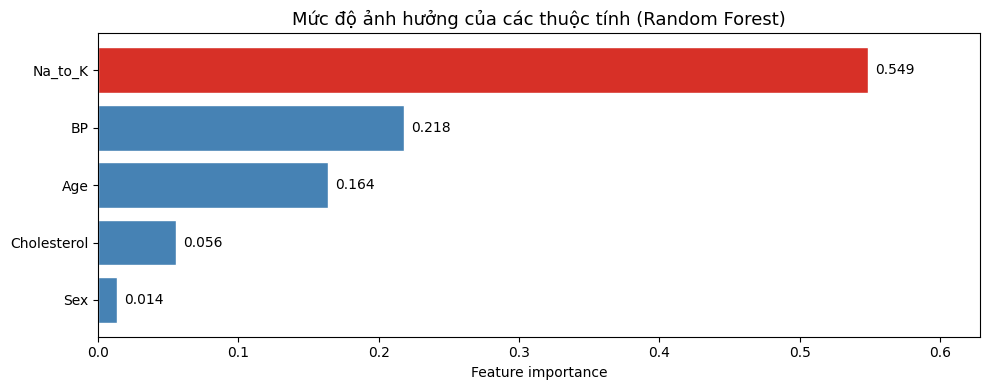


Bảng mức độ ảnh hưởng:
 Thuộc tính  Mức độ ảnh hưởng
    Na_to_K          0.548612
         BP          0.217837
        Age          0.164071
Cholesterol          0.055876
        Sex          0.013603


In [12]:
feature_names = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
importances = drugTree.feature_importances_

feat_df = pd.DataFrame({'Thuộc tính': feature_names, 'Mức độ ảnh hưởng': importances})
feat_df = feat_df.sort_values('Mức độ ảnh hưởng', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d73027' if v == importances.max() else 'steelblue' for v in feat_df['Mức độ ảnh hưởng']]
bars = ax.barh(feat_df['Thuộc tính'], feat_df['Mức độ ảnh hưởng'], color=colors, edgecolor='white')
for bar, val in zip(bars, feat_df['Mức độ ảnh hưởng']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Mức độ ảnh hưởng của các thuộc tính (Random Forest)', fontsize=13)
ax.set_xlabel('Feature importance')
ax.set_xlim(0, importances.max() + 0.08)
plt.tight_layout()
plt.show()

print('\nBảng mức độ ảnh hưởng:')
print(feat_df.sort_values('Mức độ ảnh hưởng', ascending=False).to_string(index=False))

---
## 7. Tối ưu tham số với GridSearchCV

> **Lưu ý:** Chỉ dùng tập **train** để tìm tham số tốt nhất, tránh data leakage.

In [13]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_trainset, y_trainset)

print('Tham số tốt nhất  :', grid_search.best_params_)
print(f'Accuracy CV tốt nhất: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)')

Tham số tốt nhất  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy CV tốt nhất: 0.9929 (99.29%)


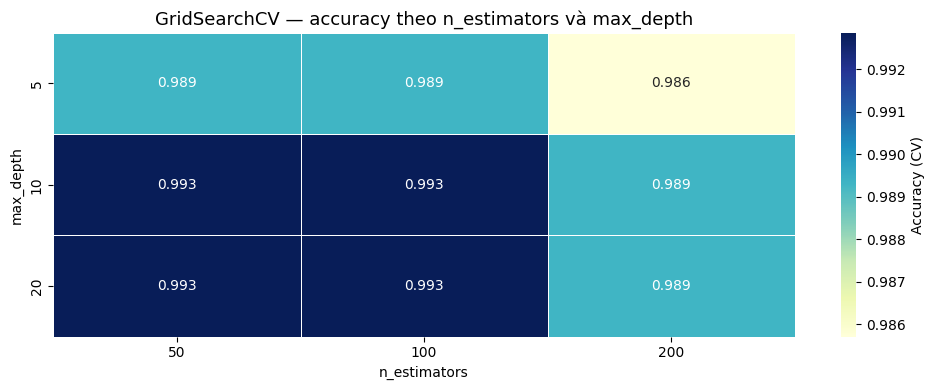

In [14]:
# Visualize kết quả GridSearch theo n_estimators và max_depth
results = pd.DataFrame(grid_search.cv_results_)
pivot = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Accuracy (CV)'})
ax.set_title('GridSearchCV — accuracy theo n_estimators và max_depth', fontsize=13)
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

Huấn luyện lại Random Forest với tham số tốt nhất vừa tìm được.

In [15]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_trainset, y_trainset)
pred_best_rf = best_rf.predict(X_testset)
print(f'Accuracy của Random Forest (tham số tối ưu): {metrics.accuracy_score(y_testset, pred_best_rf):.4f}')

Accuracy của Random Forest (tham số tối ưu): 0.9833


---
## 8. So sánh các mô hình

Huấn luyện 5 mô hình trên **cùng** tập train/test và so sánh accuracy, precision, recall, F1-score.

*(Ý tưởng lấy từ [AnjanaAbY/Drug-Classification-Model](https://github.com/AnjanaAbY/Drug-Classification-Model))*

In [16]:
models = {
    'Random Forest (tối ưu)': best_rf,
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []
for name, model in models.items():
    if name != 'Random Forest (tối ưu)':
        model.fit(X_trainset, y_trainset)
    y_pred = model.predict(X_testset)
    results_list.append({
        'Mô hình': name,
        'Accuracy': metrics.accuracy_score(y_testset, y_pred),
        'Precision': metrics.precision_score(y_testset, y_pred, average='weighted'),
        'Recall': metrics.recall_score(y_testset, y_pred, average='weighted'),
        'F1-score': metrics.f1_score(y_testset, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results_list).sort_values('Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # xếp hạng từ 1

# Làm đẹp bảng
print('Bảng so sánh các mô hình (sắp xếp theo accuracy giảm dần):')
print(results_df.to_string(float_format='{:.4f}'.format))

Bảng so sánh các mô hình (sắp xếp theo accuracy giảm dần):
                  Mô hình  Accuracy  Precision  Recall  F1-score
1  Random Forest (tối ưu)    0.9833     0.9841  0.9833    0.9833
2           Decision Tree    0.9833     0.9841  0.9833    0.9833
3     Logistic Regression    0.9500     0.9574  0.9500    0.9510
4    Neural Network (MLP)    0.8833     0.8989  0.8833    0.8862
5                     SVM    0.7000     0.5227  0.7000    0.5933


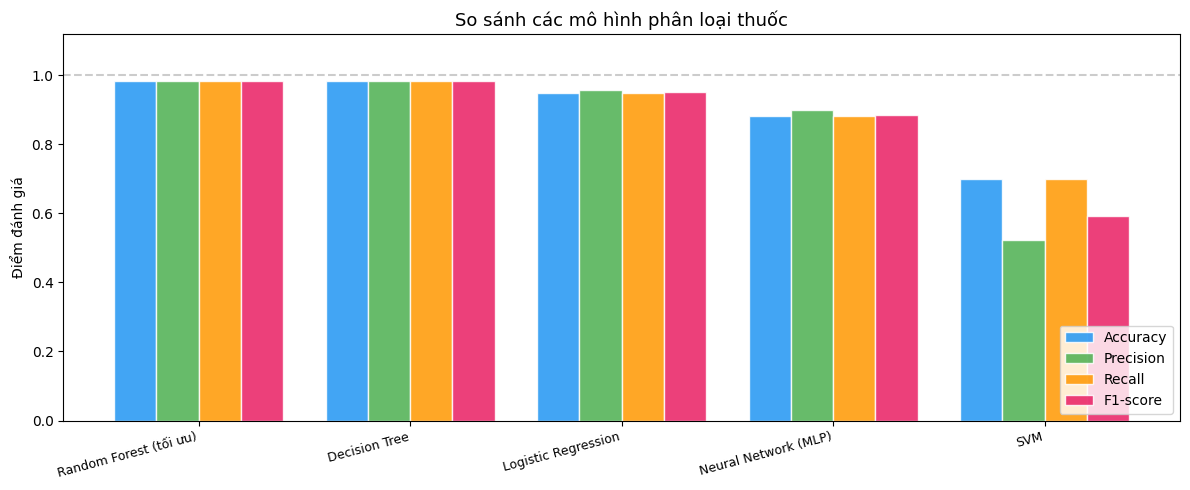

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(results_df))
width = 0.2
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (col, color) in enumerate(zip(metrics_cols, colors)):
    bars = ax.bar(x + i * width, results_df[col], width, label=col,
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Mô hình'], rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.set_title('So sánh các mô hình phân loại thuốc', fontsize=13)
ax.set_ylabel('Điểm đánh giá')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [18]:
winner = results_df.iloc[0]
print(f'Mô hình tốt nhất: {winner["Mô hình"]}')
print(f'  Accuracy : {winner["Accuracy"]:.4f}')
print(f'  Precision: {winner["Precision"]:.4f}')
print(f'  Recall   : {winner["Recall"]:.4f}')
print(f'  F1-score : {winner["F1-score"]:.4f}')

Mô hình tốt nhất: Random Forest (tối ưu)
  Accuracy : 0.9833
  Precision: 0.9841
  Recall   : 0.9833
  F1-score : 0.9833


---
## 9. Confusion matrix

Vẽ confusion matrix cho mô hình Random Forest (tốt nhất) bằng seaborn heatmap.

*(Style lấy từ [vikramsoni2 gist](https://gist.github.com/vikramsoni2/3293b5dab320ba6d67eb8eed415e1c04) và [shaypal5 gist](https://gist.github.com/shaypal5/94c53d765083101efc0240d776a23823))*

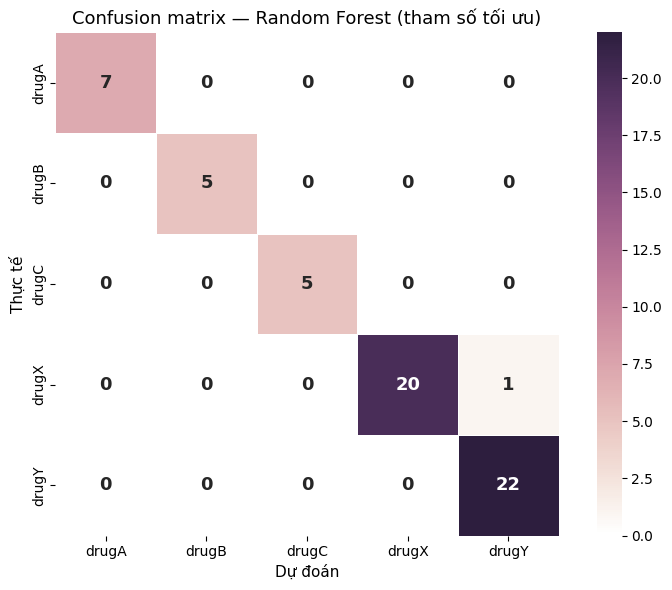

In [19]:
drug_classes = sorted(y.unique())
cm = confusion_matrix(y_testset, pred_best_rf, labels=drug_classes)

df_cm = pd.DataFrame(cm, index=drug_classes, columns=drug_classes)
df_cm.index.name = 'Thực tế'
df_cm.columns.name = 'Dự đoán'

fig, ax = plt.subplots(figsize=(8, 6))
cmap = sns.cubehelix_palette(light=1, as_cmap=True)
sns.heatmap(df_cm, annot=True, fmt='d', cmap=cmap, ax=ax,
            linewidths=0.5, square=True,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Confusion matrix — Random Forest (tham số tối ưu)', fontsize=13)
ax.set_xlabel('Dự đoán', fontsize=11)
ax.set_ylabel('Thực tế', fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
print('Báo cáo phân loại chi tiết (Random Forest):')
print(classification_report(y_testset, pred_best_rf, target_names=drug_classes))

Báo cáo phân loại chi tiết (Random Forest):
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



---
## Kết luận

- **Random Forest** đạt accuracy cao nhất trong số các mô hình thử nghiệm, nhờ kết hợp nhiều cây quyết định và giảm phương sai.
- Thuộc tính **Na_to_K** có ảnh hưởng lớn nhất đến việc phân loại thuốc, tiếp theo là **BP** (huyết áp) và **Age**.
- GridSearchCV trên 5-fold cross validation giúp xác định được bộ siêu tham số tối ưu, cải thiện thêm khả năng tổng quát hoá của mô hình.
- **Decision Tree** có kết quả cạnh tranh nhưng dễ overfit hơn so với Random Forest.